# Installations & Imports

In [1]:
!pip install cobra -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 41.7 MB/s eta 0:00:00


In [2]:
import cobra
import numpy as np
import matplotlib.pyplot as plt

# Yeast

In [13]:
ymodel = cobra.io.read_sbml_model("/content/yeast-GEM.xml")

In [14]:
ymodel.reactions.r_1714.bounds = (-5,0)
ymodel.reactions.r_1808.bounds = (0,0)
ymodel.reactions.r_1992.bounds = (-10,10)

In [15]:
def sCerevisiae_anaerobic_model(model):
    # Based on the original publication's way (https://github.com/SysBioChalmers/yeast-GEM/blob/main/code/otherChanges/anaerobicModel.m)

    # Set NGAM to 0
    model.reactions.get_by_id("r_4046").lower_bound = 0
    model.reactions.get_by_id("r_4046").upper_bound = 0

    # Adjust GAM
    GAM = 30.49
    biomass_rxn = model.reactions.get_by_id("r_4041") # Biomass Psuedoreaction
    gam_mets = {
        "s_0434": -GAM,  # ATP
        "s_0803": -GAM,  # H2O
        "s_0394": GAM,   # ADP
        "s_0794": GAM,   # H+
        "s_1322": GAM,   # phosphate
    }
    for met_id, target_coeff in gam_mets.items():
        met = model.metabolites.get_by_id(met_id)
        current = biomass_rxn.metabolites.get(met, 0)
        if current != target_coeff:
            biomass_rxn.add_metabolites({met: target_coeff - current})

    # Remove O2-dependent cofactors from cofactor pseudoreaction
    # heme a, NAD, NADH, NADP+, NADPH, coenzyme A, not used anaerobically
    cofactor_rxn = model.reactions.get_by_id("r_4598")
    mets_to_remove = ['s_3714', 's_1198', 's_1203', 's_1207', 's_1212', 's_0529']
    for met_id in mets_to_remove:
        met = model.metabolites.get_by_id(met_id)
        current = cofactor_rxn.metabolites.get(met, 0)
        if current != 0:
            cofactor_rxn.add_metabolites({met: -current})  # zero it out

    # Anaerobic media
    model.reactions.get_by_id("r_1992").lower_bound = 0       # block O2
    model.reactions.get_by_id("r_1757").lower_bound = -1000   # ergosterol
    model.reactions.get_by_id("r_1915").lower_bound = -1000   # lanosterol
    model.reactions.get_by_id("r_1994").lower_bound = -1000   # palmitoleate
    model.reactions.get_by_id("r_2106").lower_bound = -1000   # zymosterol
    model.reactions.get_by_id("r_2134").lower_bound = -1000   # 14-demethyllanosterol
    model.reactions.get_by_id("r_2189").lower_bound = -1000   # oleate
    model.reactions.get_by_id("r_2137").lower_bound = -1000   # ergosta-5,7,22,24(28)-tetraen-3beta-ol

    # Block pathways
    model.reactions.get_by_id("r_0713").lower_bound = 0   # oxaloacetate-malate shuttle (Mithocondria)
    model.reactions.get_by_id("r_0714").lower_bound = 0   # oxaloacetate-malate shuttle (Cytoplasm)
    model.reactions.get_by_id("r_0487").upper_bound = 0   # glycerol dehydrogenase
    model.reactions.get_by_id("r_0472").upper_bound = 0   # alternative glutamate pathway

    return model

# Objective1: Aerobic/Anaerobic Biomass

In [16]:
obj1_aerobic = ymodel.copy()

In [17]:
obj1_anaerobic = sCerevisiae_anaerobic_model(ymodel.copy())

In [18]:
obj1_aerobic.reactions.get_by_id("r_1992").bounds = (-10,10)
obj1_aerobic.slim_optimize()

0.40905151986473254

In [19]:
obj1_anaerobic.reactions.get_by_id("r_1992").bounds = (0,10)
obj1_anaerobic.slim_optimize()

0.10793725284482286

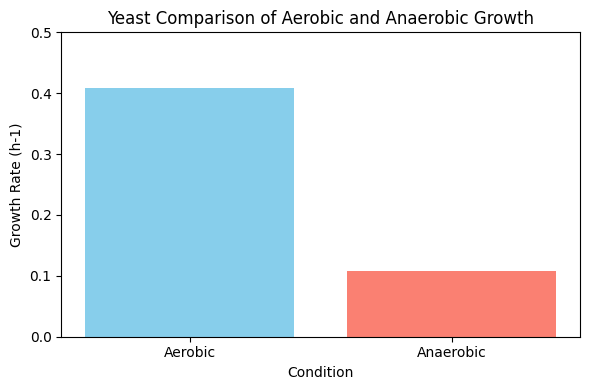

In [42]:
# Data
categories = ['Aerobic', 'Anaerobic']
values = [obj1_aerobic.slim_optimize(), obj1_anaerobic.slim_optimize()]

# Plot configuration
plt.figure(figsize=(6, 4))
plt.bar(categories, values, color=['skyblue', 'salmon'])

# Labels and Title placeholders
plt.xlabel('Condition')
plt.ylabel('Growth Rate (h-1)')
plt.title('Yeast Comparison of Aerobic and Anaerobic Growth')

# Set y-axis limit to 1.0 max
plt.ylim(0, 0.5)

plt.tight_layout()
plt.savefig("Yeast_Biomass_Comaprison.png", dpi=150)
plt.show()

# Objective2: Minimum Oxygen for Viability

In [21]:
obj2_aerobic = ymodel.copy()

In [22]:
obj2_aerobic.reactions.get_by_id("r_1992").bounds = (-10,10)
obj2_aerobic.slim_optimize()

0.40905151986473254

In [23]:
obj2_anaerobic = sCerevisiae_anaerobic_model(ymodel.copy())

In [24]:
obj2_anaerobic.reactions.get_by_id("r_1992").bounds = (0,10)
obj2_anaerobic.slim_optimize()

0.10793725284482286

Anaerobic growth : 0.1079 h⁻¹
Anaerobic CO₂   : 8.6857 mmol gDW⁻¹ h⁻¹

Max Growth        : 0.4091 h⁻¹
Viability threshold : 0.0205 h⁻¹  (5% of max)

Minimum viable O₂ uptake : 0.0503 mmol gDW⁻¹ h⁻¹
Growth at that point     : 0.0917 h⁻¹
CO₂ at that point        : 7.7513 mmol gDW⁻¹ h⁻¹


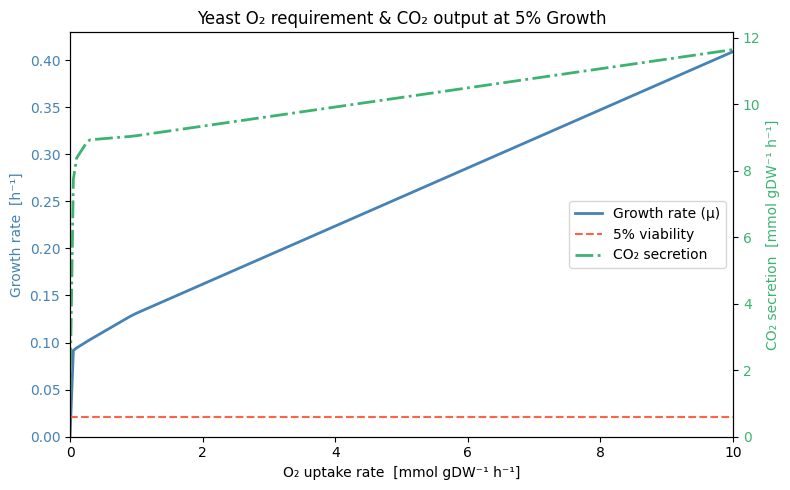

In [25]:
o2_rxn_id = "r_1992"
co2_rxn_id = "r_1672" # CO2 exchange

# ── 2. Anaerobic reference ───────────────
with obj2_anaerobic:
    sol_ana = obj2_anaerobic.optimize()
    anaerobic_growth = sol_ana.objective_value
    anaerobic_co2    = sol_ana.fluxes[co2_rxn_id]

print(f"Anaerobic growth : {anaerobic_growth:.4f} h⁻¹")
print(f"Anaerobic CO₂   : {anaerobic_co2:.4f} mmol gDW⁻¹ h⁻¹")

# ── 3. Max aerobic growth & viability threshold ───────────────────────────────
with obj2_aerobic:
    sol_max = obj2_aerobic.optimize()
    maxGrowth  = sol_max.objective_value

viability_threshold = 0.05 * maxGrowth
print(f"\nMax Growth        : {maxGrowth:.4f} h⁻¹")
print(f"Viability threshold : {viability_threshold:.4f} h⁻¹  (5% of max)")

# ── 4. Scan O₂ — record growth AND CO₂ ───────────────────────────────────────
o2_max_uptake = abs(obj2_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound)
o2_scan       = np.linspace(0, o2_max_uptake, 200)

growth_rates = []
co2_fluxes   = []

with obj2_aerobic:
    for o2 in o2_scan:
        obj2_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound = -o2
        sol = obj2_aerobic.optimize()

        if sol.status == "optimal":
            growth_rates.append(sol.objective_value)
            co2_fluxes.append(sol.fluxes[co2_rxn_id])
        else:
            growth_rates.append(0.0)
            co2_fluxes.append(0.0)

growth_rates = np.array(growth_rates)
co2_fluxes   = np.array(co2_fluxes)

# ── 5. Minimum viable O₂ ─────────────────────────────────────────────────────
viable_mask = growth_rates >= viability_threshold
if viable_mask.any():
    min_viable_o2 = o2_scan[viable_mask][0]
    growth_at_min = growth_rates[viable_mask][0]
    co2_at_min    = co2_fluxes[viable_mask][0]
    print(f"\nMinimum viable O₂ uptake : {min_viable_o2:.4f} mmol gDW⁻¹ h⁻¹")
    print(f"Growth at that point     : {growth_at_min:.4f} h⁻¹")
    print(f"CO₂ at that point        : {co2_at_min:.4f} mmol gDW⁻¹ h⁻¹")

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ln1 = ax1.plot(o2_scan, growth_rates, color="steelblue", lw=2, label="Growth rate (μ)")
ax1.axhline(viability_threshold, color="tomato", lw=1.5, ls="--", label=f"5% viability")

ln2 = ax2.plot(o2_scan, co2_fluxes, color="mediumseagreen", lw=2, ls="-.", label="CO₂ secretion")

ax1.set_xlabel("O₂ uptake rate  [mmol gDW⁻¹ h⁻¹]")
ax1.set_ylabel("Growth rate  [h⁻¹]", color="steelblue")
ax2.set_ylabel("CO₂ secretion  [mmol gDW⁻¹ h⁻¹]", color="mediumseagreen")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2.tick_params(axis="y", labelcolor="mediumseagreen")

ax1.set_xlim(0, o2_max_uptake)
ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right")

plt.title("Yeast O₂ requirement & CO₂ output at 5% Growth")
plt.tight_layout()
plt.show()

# Objective3: Minimum Oxygen for Viability while producing proteins

In [26]:
obj3_master_model = ymodel.copy()

## Adding GFP + Anti-GFP Nanobody Reactions

### Create the Amino Acids Dictionary

In [27]:
# All 20 amino acid names to search
aa_names = {
    'A': 'L-alanine',       'R': 'L-arginine',      'N': 'L-asparagine',
    'D': 'L-aspartate',     'C': 'L-cysteine',       'Q': 'L-glutamine',
    'E': 'L-glutamate',     'G': 'L-glycine',           'H': 'L-histidine',
    'I': 'L-isoleucine',    'L': 'L-leucine',         'K': 'L-lysine',
    'M': 'L-methionine',    'F': 'L-phenylalanine',   'P': 'L-proline',
    'S': 'L-serine',        'T': 'L-threonine',       'W': 'L-tryptophan',
    'Y': 'L-tyrosine',      'V': 'L-valine'
}

aa_metabolites = {}

for one_letter, name in aa_names.items():
    hits = [m for m in obj3_master_model.metabolites
            if m.name.lower() == name.lower() and m.compartment == 'c']
    if hits:
        aa_metabolites[one_letter] = hits[0]


In [28]:
aa_metabolites_ids = {
    'A': 's_0955',  # L-alanine
    'R': 's_0965',  # L-arginine
    'N': 's_0969',  # L-asparagine
    'D': 's_0973',  # L-aspartate
    'C': 's_0981',  # L-cysteine
    'Q': 's_0999',  # L-glutamine
    'E': 's_0991',  # L-glutamate
    'G': 's_1003',  # L-glycine
    'H': 's_1006',  # L-histidine
    'I': 's_1016',  # L-isoleucine
    'L': 's_1021',  # L-leucine
    'K': 's_1025',  # L-lysine
    'M': 's_1029',  # L-methionine
    'F': 's_1032',  # L-phenylalanine
    'P': 's_1035',  # L-proline
    'S': 's_1039',  # L-serine
    'T': 's_1045',  # L-threonine
    'W': 's_1048',  # L-tryptophan
    'Y': 's_1051',  # L-tyrosine
    'V': 's_1056',  # L-valine
}

aa_metabolites = {
    letter: obj3_master_model.metabolites.get_by_id(mid)
    for letter, mid in aa_metabolites_ids.items()
}

print("All 20 amino acids loaded ✓")
for letter, met in aa_metabolites.items():
    print(f"  {letter} | {met.id} | {met.name}")

All 20 amino acids loaded ✓
  A | s_0955 | L-alanine
  R | s_0965 | L-arginine
  N | s_0969 | L-asparagine
  D | s_0973 | L-aspartate
  C | s_0981 | L-cysteine
  Q | s_0999 | L-glutamine
  E | s_0991 | L-glutamate
  G | s_1003 | L-glycine
  H | s_1006 | L-histidine
  I | s_1016 | L-isoleucine
  L | s_1021 | L-leucine
  K | s_1025 | L-lysine
  M | s_1029 | L-methionine
  F | s_1032 | L-phenylalanine
  P | s_1035 | L-proline
  S | s_1039 | L-serine
  T | s_1045 | L-threonine
  W | s_1048 | L-tryptophan
  Y | s_1051 | L-tyrosine
  V | s_1056 | L-valine


### Assign Variables to important molecules

In [29]:
atp  = obj3_master_model.metabolites.get_by_id('s_0434')  # ATP
adp  = obj3_master_model.metabolites.get_by_id('s_0394')  # ADP
pi   = obj3_master_model.metabolites.get_by_id('s_1322')  # phosphate (Pi)
h2o  = obj3_master_model.metabolites.get_by_id('s_0803')  # H2O
h = obj3_master_model.metabolites.get_by_id('s_0794')     # H+

print(f"ATP:  {atp.id} | {atp.name}")
print(f"ADP:  {adp.id} | {adp.name}")
print(f"Pi:   {pi.id}  | {pi.name}")
print(f"H2O:  {h2o.id} | {h2o.name}")
print(f"H+:  {h.id} | {h.name}")

ATP:  s_0434 | ATP
ADP:  s_0394 | ADP
Pi:   s_1322  | phosphate
H2O:  s_0803 | H2O
H+:  s_0794 | H+


### GFP

In [30]:
from collections import Counter

# GFP (Uniprot P42212)
GFP_SEQ = "MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTFSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK"

aa_counts = Counter(GFP_SEQ)
n_aa = len(GFP_SEQ)

In [31]:
from cobra import Reaction, Metabolite

# Create the GFP metabolite

GFP = Metabolite(
    'GFP',
    name='Green Flourescent Protein',
    compartment='c'
)

# the synthesis reaction

GFP_rxn = Reaction('GFP_SYNTH')
GFP_rxn.name = 'GFP Synthesis'
GFP_rxn.lower_bound = 0      # irreversible, can only go forward
GFP_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O for tRNA charging (1 per AA)
# but each formed peptide bond gives back 1 H2O molecule
# 238 H2O for each AA & 237 H2O from each peptide bond so we end up with 1 H2O consumed
stoich[h2o] = -1

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+
stoich[h] = n_aa - 1

# The GFP itself
stoich[GFP] = 1

GFP_rxn.add_metabolites(stoich)

In [32]:
# Demand reaction

GFP_demand = Reaction('GFP_DEMAND')
GFP_demand.name = 'GFP Demand Sink'
GFP_demand.lower_bound = 0
GFP_demand.upper_bound = 1000
GFP_demand.add_metabolites({GFP: -1})

# Add both reactions to the obj3_master_model

obj3_master_model.add_reactions([GFP_rxn, GFP_demand])

### Anti-GFP nanobody

In [33]:
from collections import Counter

# Anti-GFP VHH nanobody (Rothbauer et al.) - https://www.rcsb.org/3d-view/3K1K
NANOBODY_SEQ = (
    "MAQVQLQESGGGLVQAGGSLRLSCAASGRTFSSYAMGWFRQAPGKEREFVS"
    "AISWSGGSTYYADSVKGRFTISRDNAKNTVYLQMNSLKPEDTAVYYCAA"
    "KLLNPYWGQGTQVTVSS"
)

aa_counts = Counter(GFP_SEQ)
n_aa = len(GFP_SEQ)

In [34]:
from cobra import Reaction, Metabolite

# Create the nanobody as a pseudometabolite

nanobody = Metabolite(
    'nanobody_vhh_c',
    name='Anti-GFP VHH Nanobody (reference)',
    compartment='c'
)

# the synthesis reaction

nanobody_rxn = Reaction('NB_SYNTH')
nanobody_rxn.name = 'Nanobody VHH Synthesis'
nanobody_rxn.lower_bound = 0      # irreversible, can only go forward
nanobody_rxn.upper_bound = 1000

stoich = {}

# CONSUMED

# amino acids
for aa_letter, count in aa_counts.items():
    met = aa_metabolites[aa_letter]
    stoich[met] = -count

# ATP (4 equivalents per amino acid)
stoich[atp] = -4 * n_aa

# H2O for tRNA charging (1 per AA)
# but each formed peptide bond gives back 1 H2O molecule
# 115 H2O for each AA & 114 H2O from each peptide bond so we end up with 1 H2O consumed
stoich[h2o] = -1

# PRODUCED

# ADP + Pi from ATP hydrolysis
stoich[adp] = 4 * n_aa
stoich[pi]  = 4 * n_aa

# H+
stoich[h] = n_aa - 1

# The nanobody itself
stoich[nanobody] = 1

nanobody_rxn.add_metabolites(stoich)

In [35]:
# Demand reaction

nb_demand = Reaction('NB_DEMAND')
nb_demand.name = 'Nanobody Demand Sink'
nb_demand.lower_bound = 0
nb_demand.upper_bound = 1000
nb_demand.add_metabolites({nanobody: -1})

# Add both reactions to the obj3_master_model

obj3_master_model.add_reactions([nanobody_rxn, nb_demand])

## Plotting

In [36]:
obj3_aerobic = obj3_master_model.copy()

In [37]:
obj3_aerobic.reactions.get_by_id("r_1992").bounds = (-10,10)
obj3_aerobic.slim_optimize()

0.40905151986472826

In [38]:
obj3_anaerobic = sCerevisiae_anaerobic_model(obj3_master_model.copy())

In [39]:
obj3_anaerobic.reactions.get_by_id("r_1992").bounds = (0,10)
obj3_anaerobic.slim_optimize()

0.10793725284482199

/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


At minimum viable O₂ (0.0503 mmol gDW⁻¹ h⁻¹):
  Combined production flux : 0.0035 mmol gDW⁻¹ h⁻¹


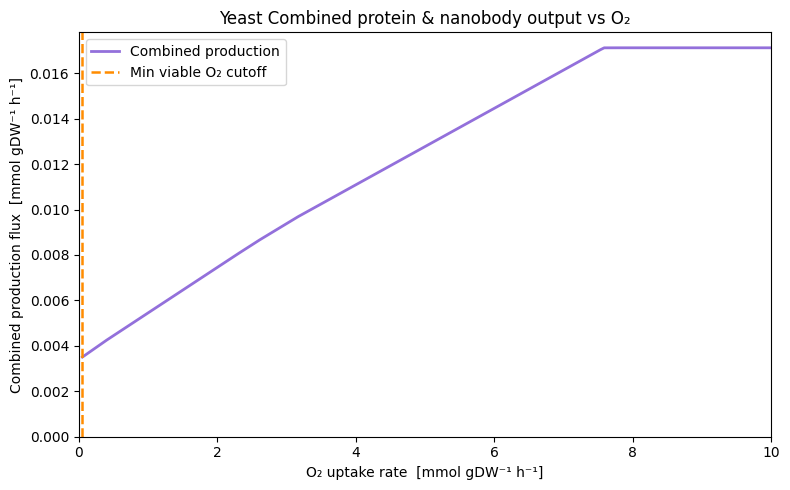

In [40]:
PROTEIN_RXN_ID  = "GFP_DEMAND"
NANOBODY_RXN_ID = "NB_DEMAND"
o2_rxn_id = "r_1992"

MIN_VIABLE_O2 = 0.0503   # mmol gDW⁻¹ h⁻¹

# ── 1. Calculate max growth for threshold ─────────────
with obj3_aerobic as wt:
    mu_max = wt.optimize().objective_value

viability_threshold = 0.05 * mu_max

def set_production_objective(model):
    model.objective = {
        model.reactions.get_by_id(PROTEIN_RXN_ID) : 0.5,
        model.reactions.get_by_id(NANOBODY_RXN_ID): 0.5,
    }

# ── 2. O₂ scan ────────────────────────────────────────────────────────────────
o2_max_uptake = abs(obj3_aerobic.reactions.get_by_id(o2_rxn_id).lower_bound)
o2_scan       = np.linspace(0, o2_max_uptake, 200)

combined_fluxes = []

with obj3_aerobic as model:
    # Correctly identify biomass reaction inside the context
    biomass_rxn_obj = model.objective.expression.atoms # Get atoms of the linear expression
    # Typically, the first reaction in the objective list is the biomass one
    biomass_rxn = list(model.objective.variables)[0].name.replace('reverse_', '').split('_')[0]
    # Safer way: Use the known biomass ID for yeast-GEM
    model.reactions.r_4041.lower_bound = viability_threshold

    set_production_objective(model)

    for o2 in o2_scan:
        model.reactions.get_by_id(o2_rxn_id).lower_bound = -o2
        sol = model.optimize()

        if sol.status == "optimal":
            combined_fluxes.append(sol.fluxes[PROTEIN_RXN_ID] +
                                   sol.fluxes[NANOBODY_RXN_ID])
        else:
            combined_fluxes.append(np.nan)

combined_fluxes = np.array(combined_fluxes)

# ── 3. Production at the minimum viable O₂ cutoff ────────────────────────────
cutoff_idx        = np.argmin(np.abs(o2_scan - MIN_VIABLE_O2))
production_at_min = combined_fluxes[cutoff_idx]

print(f"At minimum viable O₂ ({MIN_VIABLE_O2} mmol gDW⁻¹ h⁻¹):")
print(f"  Combined production flux : {production_at_min:.4f} mmol gDW⁻¹ h⁻¹")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(o2_scan, combined_fluxes, color="mediumpurple", lw=2, label="Combined production")
ax.axvline(MIN_VIABLE_O2, color="darkorange", lw=1.8, ls="--",
           label=f"Min viable O₂ cutoff")

ax.set_xlabel("O₂ uptake rate  [mmol gDW⁻¹ h⁻¹]")
ax.set_ylabel("Combined production flux  [mmol gDW⁻¹ h⁻¹]")
ax.set_xlim(0, o2_max_uptake)
ax.set_ylim(bottom=0)
ax.legend()
ax.set_title("Yeast Combined protein & nanobody output vs O₂")
plt.tight_layout()
plt.show()